In [3]:
#check the data
import pandas as pd
telemetry = pd.read_csv("C:/Users/infantshubiksha.john/OneDrive - Everrenew Energy Private Limited/Documents/Necter_assesment/telemetry.csv")
print("Telemetry shape:", telemetry.shape)

print("\nColumns:")
print(telemetry.columns.tolist())

print("\nTimestamp range:")
print(telemetry["timestamp"].min())
print(telemetry["timestamp"].max())

print("\nBuildings:")
print(telemetry["building_id"].unique())

Telemetry shape: (60480, 12)

Columns:
['timestamp', 'site_id', 'building_id', 'asset_id', 'temperature', 'humidity', 'pressure', 'vibration', 'power_consumption', 'occupancy_count', 'operating_mode', 'fault_flag']

Timestamp range:
2025-01-01 00:00:00
2025-03-01 23:00:00

Buildings:
<StringArray>
['B1', 'B2', 'B3', 'B4', 'B5', 'B6']
Length: 6, dtype: str


In [4]:
print(
    telemetry[
        ["timestamp", "building_id", "power_consumption"]
    ].head(20)
)

              timestamp building_id  power_consumption
0   2025-01-01 00:00:00          B1              29.42
1   2025-01-01 01:00:00          B1              31.46
2   2025-01-01 02:00:00          B1              27.67
3   2025-01-01 03:00:00          B1              27.35
4   2025-01-01 04:00:00          B1              28.42
5   2025-01-01 05:00:00          B1              30.68
6   2025-01-01 06:00:00          B1              32.89
7   2025-01-01 07:00:00          B1              34.46
8   2025-01-01 08:00:00          B1              37.63
9   2025-01-01 09:00:00          B1              34.27
10  2025-01-01 10:00:00          B1              38.84
11  2025-01-01 11:00:00          B1              38.12
12  2025-01-01 12:00:00          B1              34.17
13  2025-01-01 13:00:00          B1              33.38
14  2025-01-01 14:00:00          B1              37.85
15  2025-01-01 15:00:00          B1              40.60
16  2025-01-01 16:00:00          B1              37.05
17  2025-0

In [5]:
#aggregate power consumption by building and hour
energy_df = (
    telemetry
    .groupby(
        ["building_id", "timestamp"],
        as_index=False
    )["power_consumption"]
    .mean()
)

energy_df = energy_df.sort_values(
    ["building_id", "timestamp"]
).reset_index(drop=True)

print(energy_df.head())
print("\nShape:", energy_df.shape)

  building_id            timestamp  power_consumption
0          B1  2025-01-01 00:00:00          51.730000
1          B1  2025-01-01 01:00:00          49.020000
2          B1  2025-01-01 02:00:00          48.197143
3          B1  2025-01-01 03:00:00          48.915714
4          B1  2025-01-01 04:00:00          47.395714

Shape: (8640, 3)


In [7]:
# Make sure timestamp is datetime
energy_df["timestamp"] = pd.to_datetime(
    energy_df["timestamp"]
)

# Sort by building and timestamp
energy_df = energy_df.sort_values(
    ["building_id", "timestamp"]
).reset_index(drop=True)

# Check time interval
time_diff_energy = (
    energy_df
    .groupby("building_id")["timestamp"]
    .diff()
)

print("Time intervals:")
print(
    time_diff_energy
    .value_counts()
    .head(10)
)

Time intervals:
timestamp
0 days 01:00:00    8634
Name: count, dtype: int64


In [8]:
#forcasting data for all buildings
# Make sure timestamp is datetime
energy_df["timestamp"] = pd.to_datetime(
    energy_df["timestamp"]
)

# Sort chronologically
energy_df = energy_df.sort_values(
    ["building_id", "timestamp"]
).reset_index(drop=True)

print(energy_df.head())
print("\nShape:", energy_df.shape)

  building_id           timestamp  power_consumption
0          B1 2025-01-01 00:00:00          51.730000
1          B1 2025-01-01 01:00:00          49.020000
2          B1 2025-01-01 02:00:00          48.197143
3          B1 2025-01-01 03:00:00          48.915714
4          B1 2025-01-01 04:00:00          47.395714

Shape: (8640, 3)


In [9]:
#forecating features
forecast_df = energy_df.copy()

# Time features
forecast_df["hour"] = forecast_df["timestamp"].dt.hour

forecast_df["day_of_week"] = (
    forecast_df["timestamp"].dt.dayofweek
)

forecast_df["day_of_month"] = (
    forecast_df["timestamp"].dt.day
)

forecast_df["month"] = (
    forecast_df["timestamp"].dt.month
)

# Lag features calculated separately for each building
forecast_df["lag_1"] = (
    forecast_df
    .groupby("building_id")["power_consumption"]
    .shift(1)
)

forecast_df["lag_24"] = (
    forecast_df
    .groupby("building_id")["power_consumption"]
    .shift(24)
)

forecast_df["lag_168"] = (
    forecast_df
    .groupby("building_id")["power_consumption"]
    .shift(168)
)

print(forecast_df.head())

  building_id           timestamp  power_consumption  hour  day_of_week  \
0          B1 2025-01-01 00:00:00          51.730000     0            2   
1          B1 2025-01-01 01:00:00          49.020000     1            2   
2          B1 2025-01-01 02:00:00          48.197143     2            2   
3          B1 2025-01-01 03:00:00          48.915714     3            2   
4          B1 2025-01-01 04:00:00          47.395714     4            2   

   day_of_month  month      lag_1  lag_24  lag_168  
0             1      1        NaN     NaN      NaN  
1             1      1  51.730000     NaN      NaN  
2             1      1  49.020000     NaN      NaN  
3             1      1  48.197143     NaN      NaN  
4             1      1  48.915714     NaN      NaN  


In [11]:
#remove rows with missing lags
forecast_df = forecast_df.dropna().reset_index(drop=True)

print("Shape after feature engineering:")
print(forecast_df.shape)

print("\nMissing values:")
print(forecast_df.isnull().sum())

Shape after feature engineering:
(7632, 10)

Missing values:
building_id          0
timestamp            0
power_consumption    0
hour                 0
day_of_week          0
day_of_month         0
month                0
lag_1                0
lag_24               0
lag_168              0
dtype: int64


In [12]:
#define features and targets
forecast_features = [
    "hour",
    "day_of_week",
    "day_of_month",
    "month",
    "lag_1",
    "lag_24",
    "lag_168"
]

X_forecast = forecast_df[
    forecast_features
]

y_forecast = forecast_df[
    "power_consumption"
]

print("X shape:", X_forecast.shape)
print("y shape:", y_forecast.shape)

X shape: (7632, 7)
y shape: (7632,)


In [13]:
#test split
train_parts = []
test_parts = []

for building in forecast_df["building_id"].unique():

    building_data = forecast_df[
        forecast_df["building_id"] == building
    ].copy()

    building_data = building_data.sort_values(
        "timestamp"
    )

    train_parts.append(
        building_data.iloc[:-24]
    )

    test_parts.append(
        building_data.iloc[-24:]
    )

train_df = pd.concat(
    train_parts
).reset_index(drop=True)

test_df = pd.concat(
    test_parts
).reset_index(drop=True)

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

print("\nTest rows per building:")
print(test_df["building_id"].value_counts())

Training rows: 7488
Testing rows: 144

Test rows per building:
building_id
B1    24
B2    24
B3    24
B4    24
B5    24
B6    24
Name: count, dtype: int64


In [14]:
#create x/y for train and test
X_train_forecast = train_df[
    forecast_features
]

y_train_forecast = train_df[
    "power_consumption"
]

X_test_forecast = test_df[
    forecast_features
]

y_test_forecast = test_df[
    "power_consumption"
]

print("X_train:", X_train_forecast.shape)
print("X_test :", X_test_forecast.shape)
print("y_train:", y_train_forecast.shape)
print("y_test :", y_test_forecast.shape)

X_train: (7488, 7)
X_test : (144, 7)
y_train: (7488,)
y_test : (144,)


In [15]:
#train random forest
from sklearn.ensemble import RandomForestRegressor

forecast_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

forecast_model.fit(
    X_train_forecast,
    y_train_forecast
)

print("Random Forest forecasting model trained successfully.")

Random Forest forecasting model trained successfully.


In [16]:
#generate predictions
y_pred_forecast = forecast_model.predict(
    X_test_forecast
)

print("Predictions generated:", len(y_pred_forecast))
print(y_pred_forecast[:20])

Predictions generated: 144
[51.03047143 49.83315714 50.53244286 49.56882381 49.80881905 49.0563
 49.6052619  49.36984762 55.84739048 55.44987143 56.44028095 55.34199524
 55.87479524 55.6568381  56.01882381 55.97501905 56.44523333 56.06987619
 56.28779048 49.8398381 ]


In [17]:
#calculate MAE,RMSE and MAPE
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

mae = mean_absolute_error(
    y_test_forecast,
    y_pred_forecast
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_forecast,
        y_pred_forecast
    )
)

mape = np.mean(
    np.abs(
        (
            y_test_forecast - y_pred_forecast
        ) / y_test_forecast
    )
) * 100

print("Forecasting Model Performance")
print("MAE  :", round(mae, 3))
print("RMSE :", round(rmse, 3))
print("MAPE :", round(mape, 2), "%")

Forecasting Model Performance
MAE  : 1.0
RMSE : 1.409
MAPE : 2.04 %


In [19]:
#evaluate each building seperately
evaluation_results = []

for building in test_df["building_id"].unique():

    mask = (
        test_df["building_id"] == building
    )

    actual = y_test_forecast[mask]
    predicted = y_pred_forecast[mask]

    building_mae = mean_absolute_error(
        actual,
        predicted
    )

    building_rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    building_mape = np.mean(
        np.abs(
            (actual - predicted) / actual
        )
    ) * 100

    evaluation_results.append({
        "Building": building,
        "MAE": building_mae,
        "RMSE": building_rmse,
        "MAPE": building_mape
    })

evaluation_results = pd.DataFrame(
    evaluation_results
)

evaluation_results = evaluation_results.sort_values(
    "MAPE"
)

print(evaluation_results)

  Building       MAE      RMSE      MAPE
4       B5  0.599364  0.735490  1.256819
1       B2  0.817878  1.064809  1.593036
2       B3  0.996198  1.280541  1.857560
0       B1  1.139204  1.413628  2.206370
5       B6  1.024407  1.291587  2.258458
3       B4  1.425156  2.221191  3.063959


In [20]:
#create final forecast dataset
forecast_results = test_df[
    [
        "building_id",
        "timestamp"
    ]
].copy()

forecast_results["Actual_Consumption"] = (
    y_test_forecast.values
)

forecast_results["Predicted_Consumption"] = (
    y_pred_forecast
)

forecast_results["Absolute_Error"] = (
    abs(
        forecast_results["Actual_Consumption"]
        -
        forecast_results["Predicted_Consumption"]
    )
)

forecast_results.head(20)

,building_id,timestamp,Actual_Consumption,Predicted_Consumption,Absolute_Error
0,B1,2025-03-01 00:00:00,51.200000,51.030471,0.169529
1,B1,2025-03-01 01:00:00,51.232857,49.833157,1.399700
2,B1,2025-03-01 02:00:00,49.015714,50.532443,1.516729
3,B1,2025-03-01 03:00:00,48.358571,49.568824,1.210252
4,B1,2025-03-01 04:00:00,52.601429,49.808819,2.792610
5,B1,2025-03-01 05:00:00,50.761429,49.056300,1.705129
6,B1,2025-03-01 06:00:00,51.340000,49.605262,1.734738
7,B1,2025-03-01 07:00:00,51.218571,49.369848,1.848724
8,B1,2025-03-01 08:00:00,53.692857,55.847390,2.154533
9,B1,2025-03-01 09:00:00,54.780000,55.449871,0.669871


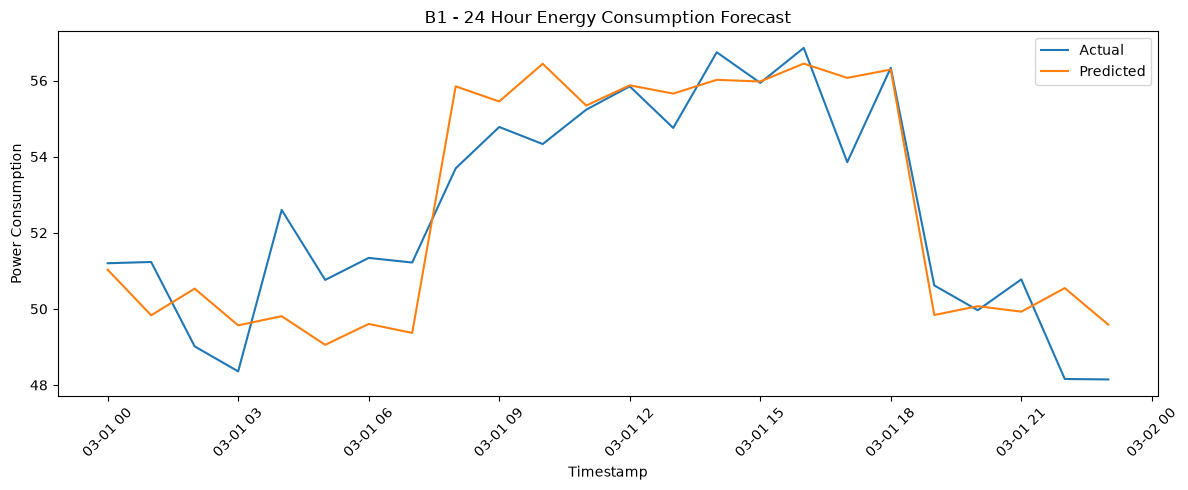

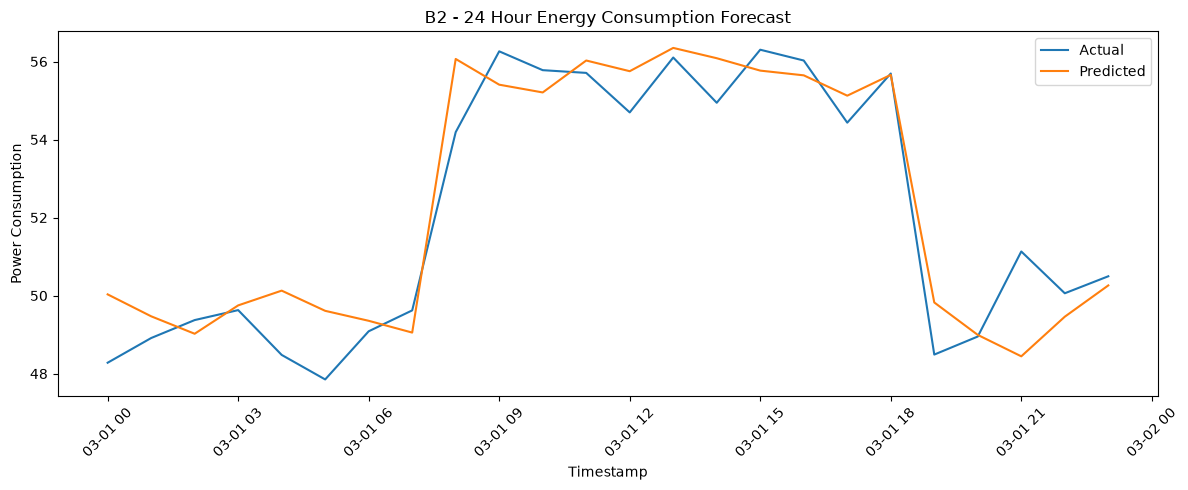

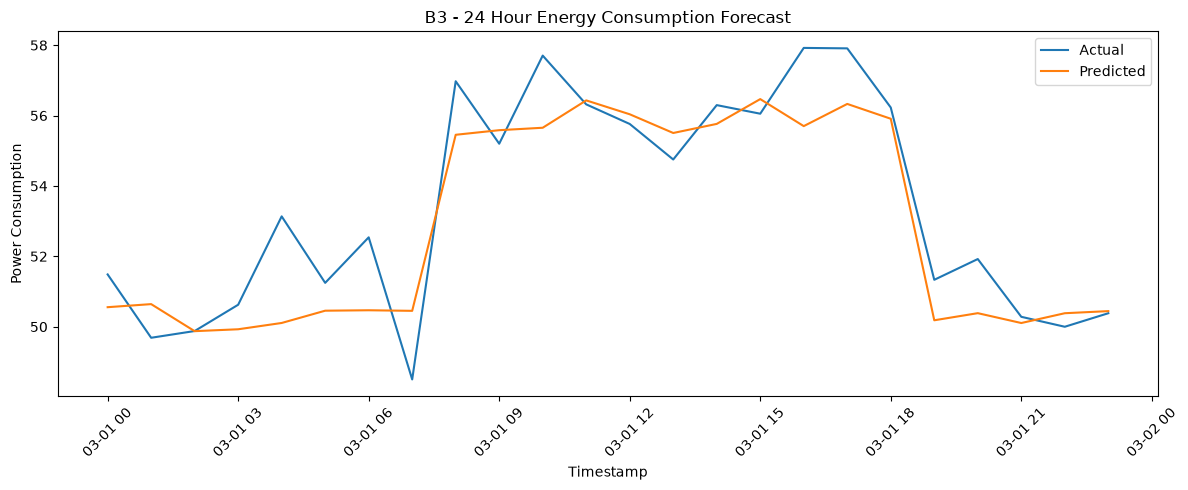

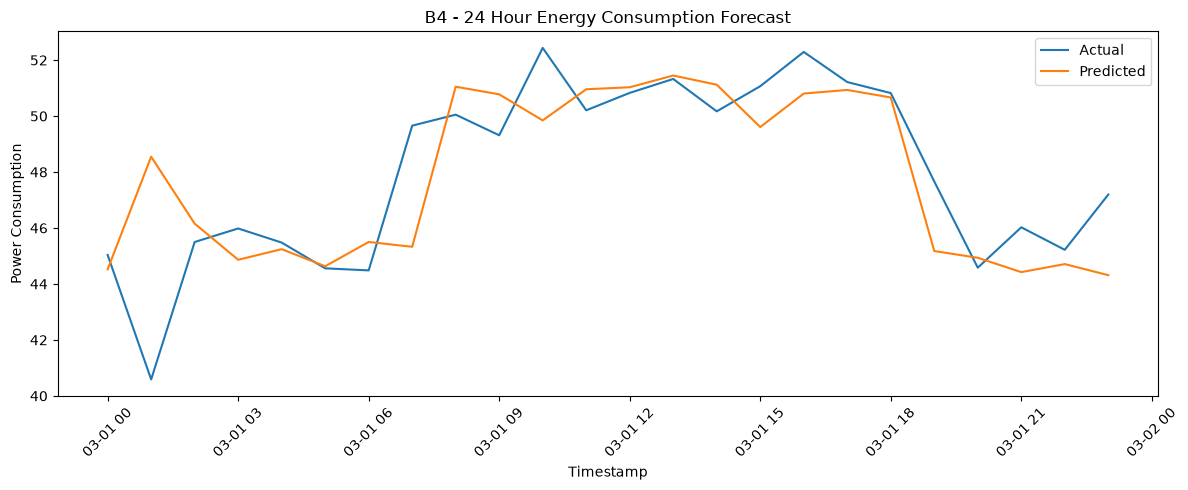

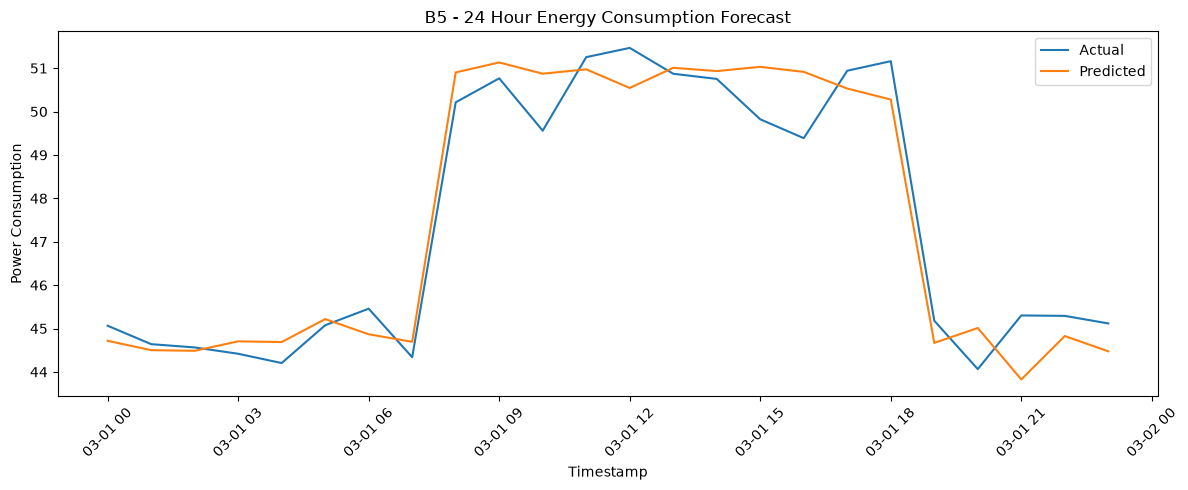

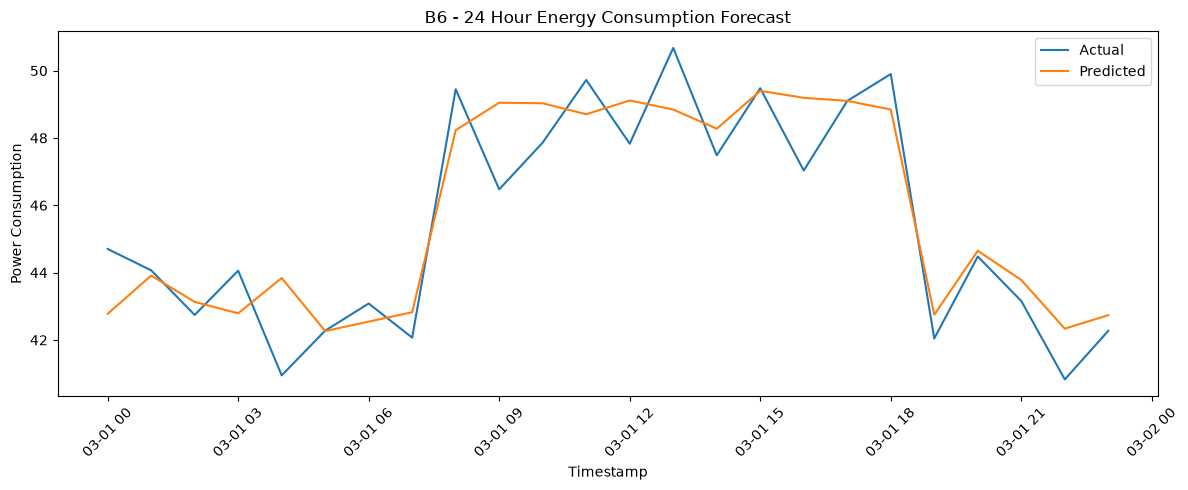

In [21]:
#plot forecast for each building
import matplotlib.pyplot as plt

for building in forecast_results["building_id"].unique():

    building_results = forecast_results[
        forecast_results["building_id"] == building
    ]

    plt.figure(figsize=(12, 5))

    plt.plot(
        building_results["timestamp"],
        building_results["Actual_Consumption"],
        label="Actual"
    )

    plt.plot(
        building_results["timestamp"],
        building_results["Predicted_Consumption"],
        label="Predicted"
    )

    plt.title(
        f"{building} - 24 Hour Energy Consumption Forecast"
    )

    plt.xlabel("Timestamp")
    plt.ylabel("Power Consumption")

    plt.xticks(rotation=45)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [22]:
#find the highest predicted consumption
peak_consumption = (
    forecast_results
    .sort_values(
        "Predicted_Consumption",
        ascending=False
    )
)

print(
    peak_consumption[
        [
            "building_id",
            "timestamp",
            "Predicted_Consumption"
        ]
    ].head(20)
)

   building_id           timestamp  Predicted_Consumption
63          B3 2025-03-01 15:00:00              56.468086
16          B1 2025-03-01 16:00:00              56.445233
10          B1 2025-03-01 10:00:00              56.440281
59          B3 2025-03-01 11:00:00              56.431471
37          B2 2025-03-01 13:00:00              56.349076
65          B3 2025-03-01 17:00:00              56.330800
18          B1 2025-03-01 18:00:00              56.287790
38          B2 2025-03-01 14:00:00              56.084857
17          B1 2025-03-01 17:00:00              56.069876
32          B2 2025-03-01 08:00:00              56.065738
60          B3 2025-03-01 12:00:00              56.037062
35          B2 2025-03-01 11:00:00              56.026286
14          B1 2025-03-01 14:00:00              56.018824
15          B1 2025-03-01 15:00:00              55.975019
66          B3 2025-03-01 18:00:00              55.909776
12          B1 2025-03-01 12:00:00              55.874795
8           B1

In [23]:
#find avg predicted consumption by building
building_forecast_summary = (
    forecast_results
    .groupby("building_id")
    .agg(
        Average_Predicted_Consumption=(
            "Predicted_Consumption",
            "mean"
        ),
        Peak_Predicted_Consumption=(
            "Predicted_Consumption",
            "max"
        ),
        Minimum_Predicted_Consumption=(
            "Predicted_Consumption",
            "min"
        )
    )
    .reset_index()
)

print(building_forecast_summary)

  building_id  Average_Predicted_Consumption  Peak_Predicted_Consumption  \
0          B1                      52.674369                   56.445233   
1          B2                      52.353688                   56.349076   
2          B3                      52.867216                   56.468086   
3          B4                      47.774525                   51.449010   
4          B5                      47.491966                   51.132052   
5          B6                      45.755370                   49.399033   

   Minimum_Predicted_Consumption  
0                      49.056300  
1                      48.443981  
2                      49.873229  
3                      44.313724  
4                      43.826643  
5                      42.265214  


In [24]:
#feature importance
forecast_feature_importance = pd.DataFrame({
    "Feature": forecast_features,
    "Importance": forecast_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print(forecast_feature_importance)

        Feature  Importance
5        lag_24    0.536729
6       lag_168    0.403281
4         lag_1    0.026523
2  day_of_month    0.012496
0          hour    0.012245
1   day_of_week    0.006862
3         month    0.001864


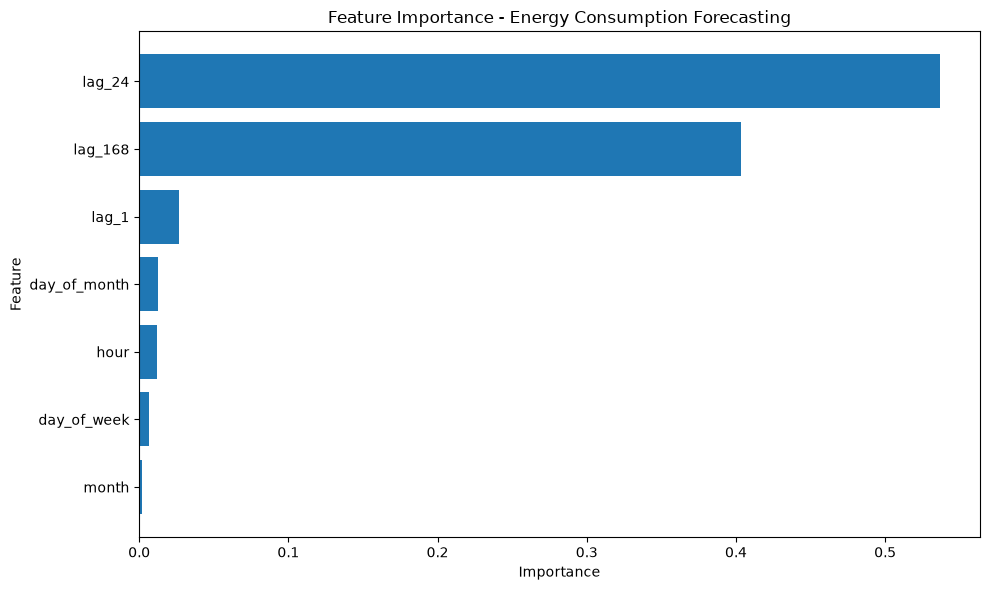

In [25]:
#plot
plt.figure(figsize=(10, 6))

plt.barh(
    forecast_feature_importance["Feature"],
    forecast_feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Feature Importance - Energy Consumption Forecasting"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

Conclusion

- The Random Forest model was used to forecast the next 24 hours of energy consumption for all six buildings.
- Model performance was evaluated using MAE, RMSE, and MAPE.
- The building-wise evaluation shows differences in forecasting accuracy across B1–B6.
- The forecast plots compare predicted energy consumption with actual consumption patterns over the 24-hour test period.
- Historical consumption features, including recent hourly, daily, and weekly lag values, provided useful information for predicting future energy demand.
- The forecast can support proactive energy optimization by identifying upcoming periods of high energy consumption.
- Buildings and time periods with higher predicted consumption can be prioritized for energy-saving actions and operational planning.